Phase 7: Table Understanding
Objective: Crop a table region, detect rows/columns using OpenCV morphology, and OCR individual cells to build structured data.

Detected 14 rows.

--- RAW ROW DATA ---
Row 0: “Gur model | Urich affine UNK, qu’ 1's" membre agi du dune cons pratique administration depls du des annes pou que les tlephones Rad?
Row 1: Portables pulsent te collects avant les reunions du consell afin qu” is
Row 2: one be Solent Hacenerg- pas ullsés comme apparels. écoue distnce di ATT
Row 3: ‘éclare que la collect lies membre des telephones consi portables avant écoute ls a distance. réuions du consll afin gus
Row 4: epuls be pulsset des années pas ere comme est ue pique courante
Row 5: Dar model ptendellement ul Sot des interttrences Uh les apparels Tan STA de navigation, pane gO TS
Row 6: pouratent ous savons. sont elo dans la FCC. qu’ ls pouraia ave avec les tours de lephone celulae mals
Row 7: Teese’ ae", dit ve UNE
Row 8: Ta eps éventuellement anes St des ETT lrenes ON RODENT les instruments SATEEN de navigation PARTE HTT
Row 9: Farce que nous mabe savons ss Son crt apes tls la FCC intr bord”, qu" pouraieat a dclare avec Rosenke

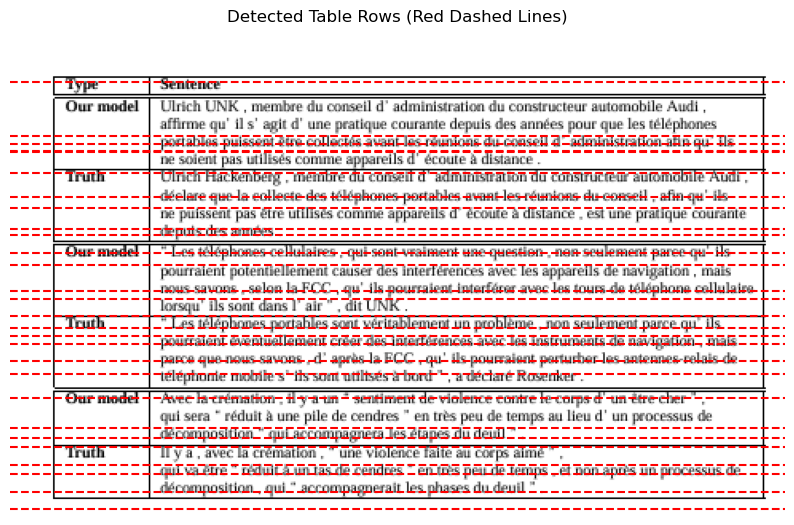

In [14]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import cv2
import numpy as np
import pandas as pd
import pytesseract
import matplotlib.pyplot as plt

# 1. Load Image
img_path = "../data/raw/table_1.png"
img = cv2.imread(img_path)

if img is None:
    print("Error: Could not load image.")
else:
    # 2. Get OCR data (text + bounding boxes)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    data = pytesseract.image_to_data(gray, output_type=pytesseract.Output.DICT, config='--psm 6')
    
    # 3. Filter valid OCR tokens
    tokens = []
    for i in range(len(data['text'])):
        text = data['text'][i].strip()
        conf = int(data['conf'][i])
        if text and conf > 0:
            x, y, w, h = data['left'][i], data['top'][i], data['width'][i], data['height'][i]
            tokens.append({
                'text': text,
                'x1': x, 'y1': y, 'x2': x+w, 'y2': y+h,
                'center_y': y + h/2
            })
            
    if not tokens:
        print("No text found in image!")
    else:
        # 4. Group tokens into Rows using Y-coordinates
        # If two words have a similar Y-center, they are on the same row.
        tokens.sort(key=lambda t: t['y1'])
        
        rows = []
        current_row = [tokens[0]]
        
        for token in tokens[1:]:
            # If the token's Y-center is within 15 pixels of the current row's average Y-center
            avg_y = sum([t['center_y'] for t in current_row]) / len(current_row)
            if abs(token['center_y'] - avg_y) < 15:
                current_row.append(token)
            else:
                rows.append(current_row)
                current_row = [token]
        rows.append(current_row) # Add the last row
        
        # 5. Sort tokens in each row by X-coordinate (Left to Right)
        for row in rows:
            row.sort(key=lambda t: t['x1'])
            
        # 6. Build the 2D Array (Table)
        table_data = []
        for row in rows:
            row_text = " ".join([t['text'] for t in row])
            table_data.append(row_text)
            
        # 7. Display as DataFrame
        print(f"Detected {len(rows)} rows.")
        print("\n--- RAW ROW DATA ---")
        for i, row in enumerate(table_data):
            print(f"Row {i}: {row}")
            
        # Visualize the detected rows
        plt.figure(figsize=(10, 10))
        plt.imshow(gray, cmap='gray')
        
        # Draw row boundaries
        colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0)]
        for i, row in enumerate(rows):
            min_y = min([t['y1'] for t in row])
            max_y = max([t['y2'] for t in row])
            plt.axhline(min_y, color='red', linestyle='--')
            plt.axhline(max_y, color='red', linestyle='--')
            
        plt.title("Detected Table Rows (Red Dashed Lines)")
        plt.axis('off')
        plt.show()